In [1]:
import random
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [2]:
def plot_smart_boxplots(df: pd.DataFrame) -> list:
    sns.set_theme(style="whitegrid", palette="pastel")
    num_cols_raw = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [col for col in num_cols_raw if df[col].nunique() > 10]
    n_features = len(num_cols)
    if n_features == 0:
        return []
    if n_features <= 3:
        cols_in_row = n_features
    elif n_features == 4:
        cols_in_row = 2
    else:
        cols_in_row = 3 if n_features < 10 else 4
    rows = math.ceil(n_features / cols_in_row)
    fig, axes = plt.subplots(rows, cols_in_row,
                             figsize=(cols_in_row * 5, rows * 5),
                             squeeze=False)
    axes = axes.flatten()
    colors = sns.color_palette("pastel", n_colors=n_features)
    for i, col in enumerate(num_cols):
        ax = axes[i]
        sns.boxplot(
            y=df[col], 
            ax=ax, 
            color=colors[i],
            width=0.4,
            fliersize=3,
            linewidth=1.5
        )
        ax.set_title(f"{col}", fontsize=14, fontweight='bold', pad=15)
        ax.set_ylabel('')
    for j in range(n_features, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()
    return num_cols

# Смотрим данные

In [3]:
data = pd.read_csv('data/housing.csv', delimiter=';')
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700


In [4]:
data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
dtype: int64

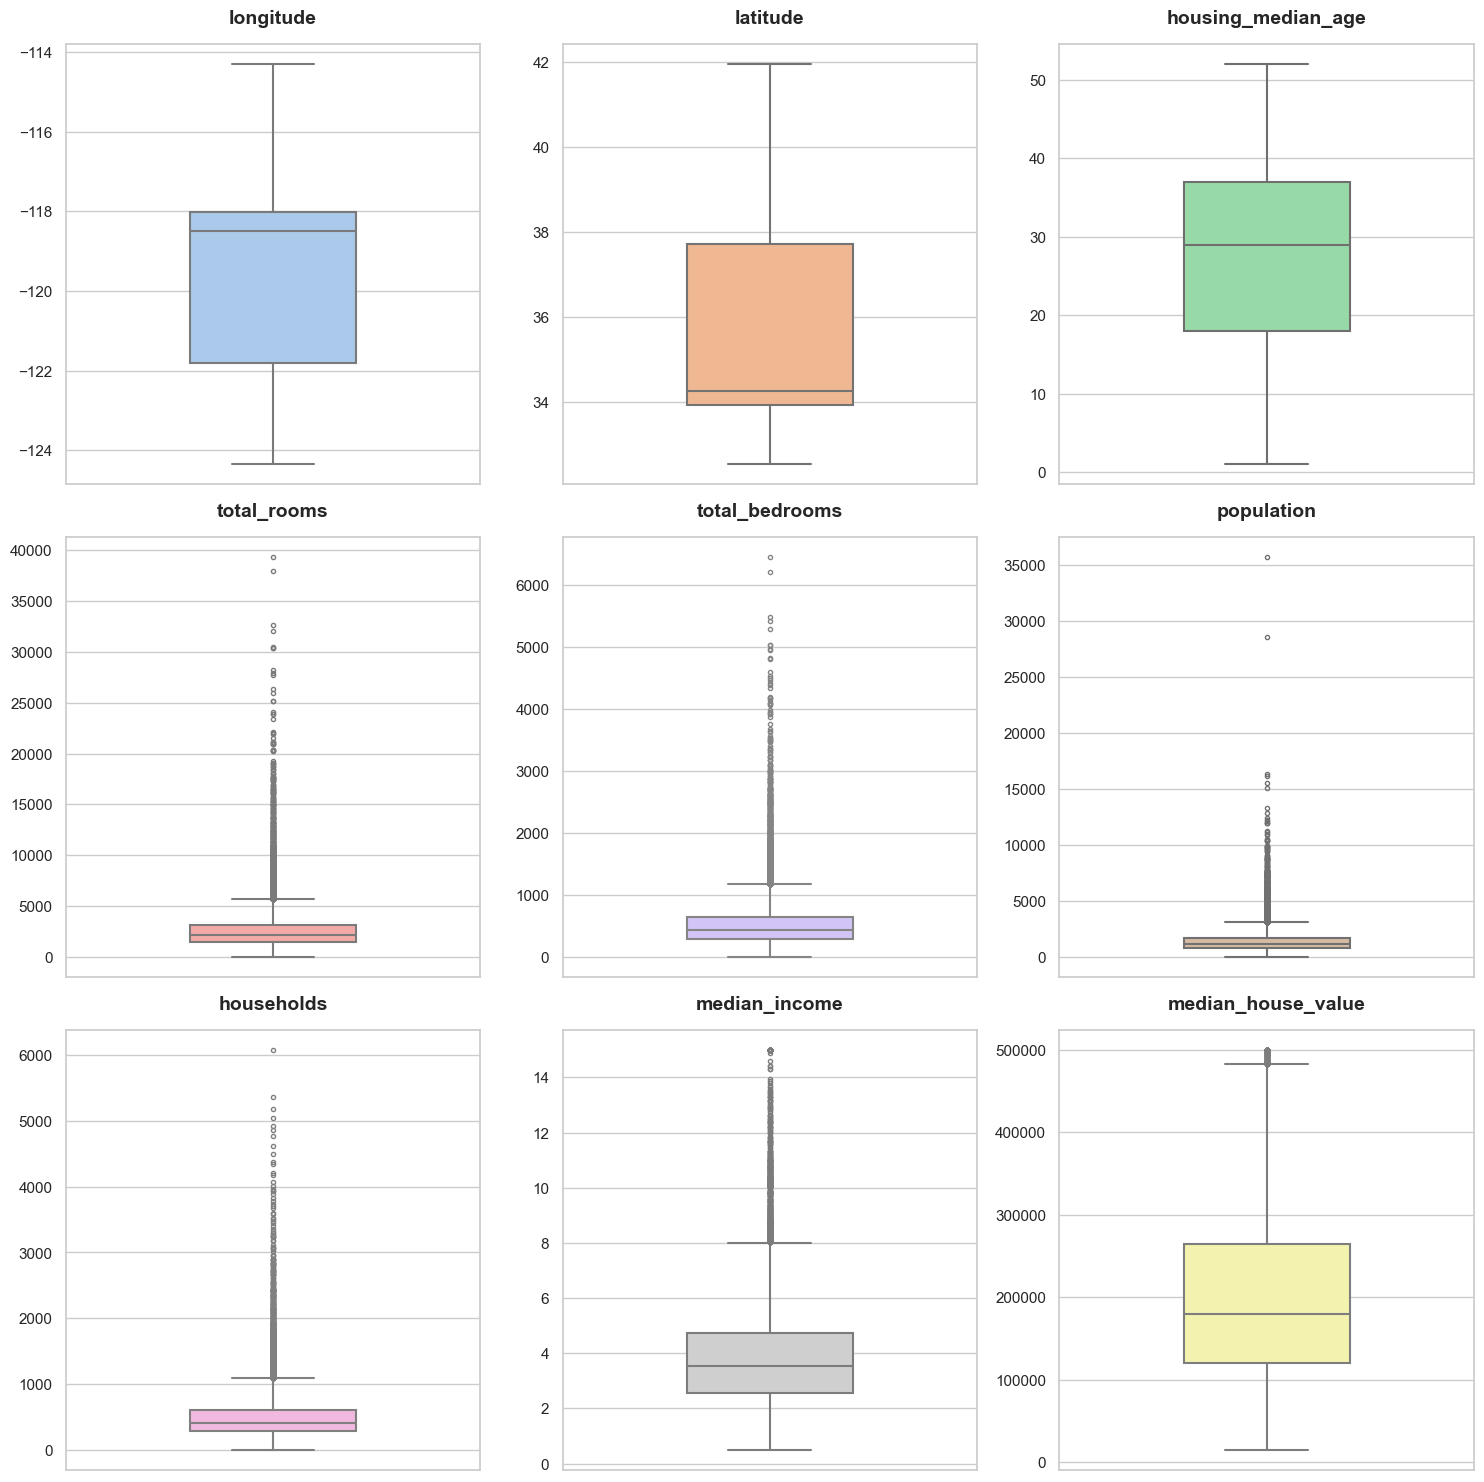

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

In [5]:
plot_smart_boxplots(data)

In [6]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
data.fillna(data.median(), inplace=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700


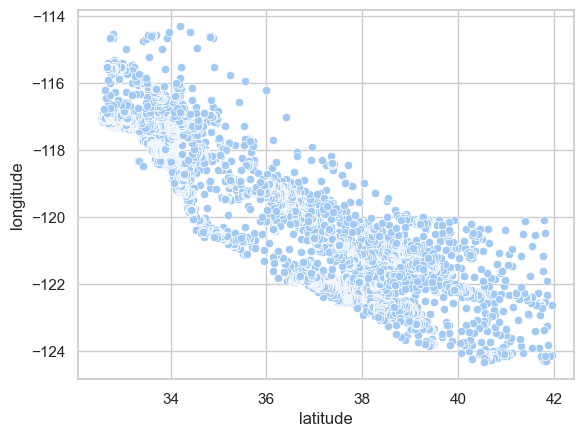

In [8]:
sns.scatterplot(data=data, x="latitude", y="longitude");

In [9]:
fig = px.scatter_mapbox(data, lat="latitude", lon="longitude",
                        mapbox_style="open-street-map", zoom=4)
fig.show()

/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_88209/895364316.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(data, lat="latitude", lon="longitude",


Данные с штата Калифорния в дальнейшем можно прикольные данные из этого взять

# Класс линейной регрессии и метрики

В ообще самая простая реалиация и вид линейной регрессии такой

$$
f(x) = Xw \\
X \text{ - матрица, наши данные где колонки - это признаки, а строки - просто следующие данные которые надо рассчитать} \\
 w \text{ - наши веса}
$$

В теории лабы написано что есть еще случайная ошиба, но в большинстве источников все ее сокращают и убирают из формулы [один из источникв](https://github.com/esokolov/ml-course-hse/blob/master/ml1-2026-spring/lecture-notes/lecture02-linregr.pdf)

Теперь связь со СЛАУ и МНК и тд, в чем вообще прикол, если пришлядеться то можно увидеть вообще такую картину

$$
Xw=y
$$

По факту наше СЛАУ ищим вектор весов $w$ чтобы получить наши таргеты $y$

Теперь причем тут МНК, если мы просто вычислим $w$ то какое-то отличие всеравно будет, и поэтому можно применить МНК, вычисляя веса так чтобы ошибка была минимальной

Ошибка выглядит так

$$
error = ||Xw - y|| ^ 2
$$

распишем

$$
error = ||Xw - y|| ^ 2 = (Xw - y)^T(Xw - y)= (w^TX^T - y^T)(Xw - y) = w^TX^TXw − w^TX^Ty − y^TXw + y^Ty \\
$$

$$
w^TX^Ty = (w^TX^Ty)^T = y^TXw
$$

$$
error = w^TX^TXw − 2w^TX^Ty + y^Ty
$$

Теперь посчитаем градиент

$$
\nabla error_w = 2X^TXw - 2X^Ty + 0
$$

$$
\nabla error_w = 2X^TXw - 2X^Ty
$$

Теперь нам нужен минимум ошибки, что делаем? очев

$$
\nabla error_w = 0
$$

$$
2X^TXw - 2X^Ty = 0
$$

$$
2X^TXw = 2X^Ty
$$

и тут мы получили СЛАУ, ищим мы $w$

$$
w = (X^TX)^{-1}X^Ty
$$

и по факту все, это как один из способов, либо можно искать веса через градиентный спуск

МНК это вообще наш критерий что он говорит, минимизируем квадрат ошибки и все 

In [10]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

In [35]:
def evaluate_models(models, X_test, y_test):
    results = []
    for name, model in models.items():
        preds = model.predict(X_test)
        mae = mean_absolute_error(y_test, preds)
        mse = mean_squared_error(y_test, preds)
        rmse = mse ** 0.5
        r2 = r2_score(y_test, preds)
        results.append({
            "Model": name,
            "MAE": f"{mae:.4f}",
            "RMSE": f"{rmse:.4f}",
            "MSE": f"{mse:.4f}",
            "R²": f"{r2:.4f}",
        })
    df = pd.DataFrame(results).set_index("Model")
    return df

In [36]:
class LinearRegression:
    def __init__(self):
        self.w = None

    def fit(self, X, y, fit_var: str='inv', iter: int=1024, learning_rate: float=0.01, eps: float= 1e-8, delta: float=1e-8):
        if fit_var == 'inv':
            self.w = np.linalg.inv(X.T @ X) @ X.T @ y
        elif fit_var == 'solve':
            self.w = np.linalg.solve(X.T @ X, X.T @ y)
        elif fit_var == 'lstsq':
            self.w, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        elif fit_var == 'grad':
            self._fit_gradient_lin_reg(X, y, iter, learning_rate, eps, delta)
        else:
            raise ValueError(f"Unknown fit_var: {fit_var}")
    
    def _fit_gradient_lin_reg(self, X, y, iter, learning_rate, eps, delta):
        self.w = np.random.rand(X.shape[1])
        best_w = self.w.copy()
        best_error = np.inf
        for i in range(iter):
            pred = X @ self.w
            error = np.mean(np.abs(pred - y) ** 2)
            grad = 2 * X.T @ X @ self.w - 2 * X.T @ y
            self.w -= learning_rate * grad
            if error < best_error:
                best_error = error
                best_w = self.w.copy()
            if error < eps or np.linalg.norm(grad) < delta:
                break
            print(f'Iter {i}: {error}')
        self.w = best_w

    def predict(self, X):
        return X @ self.w

# Делаем деление данных на таргет и признаки, потом на валидацию и треин

## Делим

In [37]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200


In [38]:
X = data.drop(columns=["median_house_value"]).values
Y = data["median_house_value"].values

In [39]:
X_train, X_valid, Y_train, Y_valid = train_test_split(
    X, Y, test_size=0.2, random_state=SEED
)

## Посмотр метрики без предобработок

In [40]:
lr_inv = LinearRegression()
lr_inv.fit(X_train, Y_train, fit_var='inv')

lr_solve = LinearRegression()
lr_solve.fit(X_train, Y_train, fit_var='solve')

lr_lstsq = LinearRegression()
lr_lstsq.fit(X_train, Y_train, fit_var='lstsq')

lr_grad = LinearRegression()
lr_grad.fit(X_train, Y_train, fit_var='grad', iter=32)

Iter 0: 55423450013.08183
Iter 1: 7.379659042537977e+29
Iter 2: 1.9538642091794312e+49
Iter 3: 5.1731289641539875e+68
Iter 4: 1.3696582992428485e+88
Iter 5: 3.6263620522208153e+107
Iter 6: 9.601301099009007e+126
Iter 7: 2.5420788511002835e+146
Iter 8: 6.730509561749216e+165
Iter 9: 1.7819966104194842e+185
Iter 10: 4.71808544421893e+204
Iter 11: 1.2491791582987596e+224
Iter 12: 3.3073766636422726e+243
Iter 13: 8.756742635782378e+262
Iter 14: 2.3184701770521623e+282
Iter 15: 6.13847429969606e+301
Iter 16: inf
Iter 17: inf
Iter 18: inf
Iter 19: inf
Iter 20: inf
Iter 21: inf
Iter 22: inf
Iter 23: inf
Iter 24: inf
Iter 25: inf
Iter 26: inf
Iter 27: inf
Iter 28: inf
Iter 29: inf
Iter 30: inf
Iter 31: inf


/var/folders/8w/ywmr9zq5375c02ys9s23g0xh0000gn/T/ipykernel_88209/3659527579.py:23: RuntimeWarning: overflow encountered in square
  error = np.mean(np.abs(pred - y) ** 2)


In [41]:
evaluate_models(
    {'Linear Regression (Inv)': lr_inv,
     'Linear Regression (Solve)': lr_solve,
     'Linear Regression (Lstsq)': lr_lstsq,
     'Linear Regression (Grad)': lr_grad},
    X_valid, Y_valid)

,MAE,RMSE,MSE,R²
Model,,,,
Linear Regression (Inv),56141.7034,76005.2304,5776795045.1942,0.5592
Linear Regression (Solve),56141.7034,76005.2304,5776795045.1941,0.5592
Linear Regression (Lstsq),56141.7034,76005.2304,5776795045.1947,0.5592
Linear Regression (Grad),666379093498045.0000,856324507782725.6250,733291662629327384422138249216.0000,-55958992559231557632.0000


In [ ]:
XTX = X_train.T @ X_train

cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond:.2e}")

Число обусловленности X^T X: 8.99e+06


## StandardScaler с параметрами with_mean и with_std

In [19]:
scaler = StandardScaler(with_mean=True, with_std=True)
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

In [20]:
lr = LinearRegression(n_jobs=-1)
lr.fit(X_train_scaled, Y_train)

TypeError: LinearRegression.__init__() got an unexpected keyword argument 'n_jobs'

In [ ]:
evaluate_models({'Linear Regression': lr}, X_valid_scaled, Y_valid)

,MAE,MSE,RMSE,R²
Model,,,,
Linear Regression,51810.483628,5.059928e+09,71133.173493,0.613866


In [ ]:
XTX = X_train_scaled.T @ X_train_scaled

# Число обусловленности
cond = np.linalg.cond(XTX)
print(f"Число обусловленности X^T X: {cond:.2e}")

Число обусловленности X^T X: 2.66e+02
